# 10年定着予測 - データ探索的分析（EDA）

## 概要
- **課題**: 入社後2年間（0-23ヶ月）のデータから、入社10年後（120ヶ月時点）の在籍を予測
- **評価指標**: Log Loss（対数損失）
- **データ**: 属性データ（社員1名=1行）+ 月次データ（社員×月=複数行）

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# プロジェクトルートの設定
PROJECT_ROOT = Path("/Workspace/Users/1122hkaito@gmail.com/jaggle_2026")
INPUT_DIR = PROJECT_ROOT / "data" / "input"

# データ読み込み
train_persona = pd.read_csv(INPUT_DIR / "employee_persona_train.csv")
test_persona = pd.read_csv(INPUT_DIR / "employee_persona_test.csv")
train_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_train.csv")
test_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_test.csv")
train_monthly_full = pd.read_csv(INPUT_DIR / "employee_monthly_train_full.csv")

print("✓ データ読み込み完了")

✓ データ読み込み完了


## 1. 基本情報の確認

まず、各データセットの基本的な情報を確認します。

In [0]:
# データセットの基本情報
print("="*60)
print("データセットサイズ")
print("="*60)
print(f"Train 属性データ: {train_persona.shape[0]:,}行 × {train_persona.shape[1]}列")
print(f"Test 属性データ:  {test_persona.shape[0]:,}行 × {test_persona.shape[1]}列")
print(f"Train 月次データ: {train_monthly.shape[0]:,}行 × {train_monthly.shape[1]}列")
print(f"Test 月次データ:  {test_monthly.shape[0]:,}行 × {test_monthly.shape[1]}列")
print(f"Train 月次データ(Full): {train_monthly_full.shape[0]:,}行 × {train_monthly_full.shape[1]}列")
print()

# 属性データのカラム一覧
print("="*60)
print("属性データのカラム一覧")
print("="*60)
for i, col in enumerate(train_persona.columns, 1):
    print(f"{i:2d}. {col}")

データセットサイズ
Train 属性データ: 2,761行 × 20列
Test 属性データ:  2,502行 × 19列
Train 月次データ: 65,754行 × 29列
Test 月次データ:  60,048行 × 29列
Train 月次データ(Full): 257,509行 × 29列

属性データのカラム一覧
 1. 社員ID
 2. 入社日
 3. 入社区分
 4. 入社時年齢
 5. 最終学歴
 6. 専攻分野
 7. 前職経験月数
 8. 前職職種
 9. 採用経路
10. 性別
11. 初期職種
12. 初期部署ID
13. 初期勤務地
14. 初期等級
15. 初期役割
16. 初任給_円
17. 入社時メモ
18. 上司からのフィードバック
19. 同僚からのフィードバック
20. 10年定着ラベル


In [0]:
# 月次データのカラム一覧
print("="*60)
print("月次データのカラム一覧")
print("="*60)
for i, col in enumerate(train_monthly.columns, 1):
    print(f"{i:2d}. {col}")

月次データのカラム一覧
 1. 社員ID
 2. 年月
 3. 経過月数
 4. 年齢
 5. 月末在籍状態
 6. 部署ID
 7. 職種
 8. 役割
 9. 等級
10. 上司ID
11. 勤務地
12. 月例給与_円
13. 360度評価_親和度
14. 360度評価_信頼度
15. 360度評価_主体度
16. 360度評価_学習度
17. 360度評価_共有貢献度
18. 360度評価更新フラグ
19. 360度評価者数
20. 担当プロジェクト数
21. 顧客満足度評価
22. 残業時間
23. 有給取得日数
24. 欠勤日数
25. 研修時間
26. 自己学習（詳細）
27. 上司との面談実施回数
28. 情報共有件数
29. 在宅勤務日数


In [0]:
# 属性データの欠損値
print("="*60)
print("属性データ（Train）の欠損値")
print("="*60)
missing_persona = train_persona.isnull().sum()
missing_persona = missing_persona[missing_persona > 0].sort_values(ascending=False)
if len(missing_persona) > 0:
    for col, count in missing_persona.items():
        pct = 100 * count / len(train_persona)
        print(f"{col:30s}: {count:5d}件 ({pct:5.2f}%)")
else:
    print("欠損なし")

print()

# 月次データの欠損値
print("="*60)
print("月次データ（Train）の欠損値")
print("="*60)
missing_monthly = train_monthly.isnull().sum()
missing_monthly = missing_monthly[missing_monthly > 0].sort_values(ascending=False)
if len(missing_monthly) > 0:
    for col, count in missing_monthly.items():
        pct = 100 * count / len(train_monthly)
        print(f"{col:30s}: {count:6d}件 ({pct:5.2f}%)")
else:
    print("欠損なし")

属性データ（Train）の欠損値
前職職種                          :  2025件 (73.34%)

月次データ（Train）の欠損値
顧客満足度評価                       :  42969件 (65.35%)
担当プロジェクト数                     :  31228件 (47.49%)
360度評価_親和度                    :  13593件 (20.67%)
360度評価_信頼度                    :  13593件 (20.67%)
360度評価_主体度                    :  13593件 (20.67%)
360度評価_学習度                    :  13593件 (20.67%)
360度評価_共有貢献度                  :  13593件 (20.67%)
360度評価者数                      :  13593件 (20.67%)


## 2. 目的変数（10年定着ラベル）の分析

定着率とクラスバランスを確認します。

10年定着ラベルの分布
定着（1）: 1,559名 (56.47%)
退職（0）: 1,202名 (43.53%)

定着率: 0.5647 (56.47%)


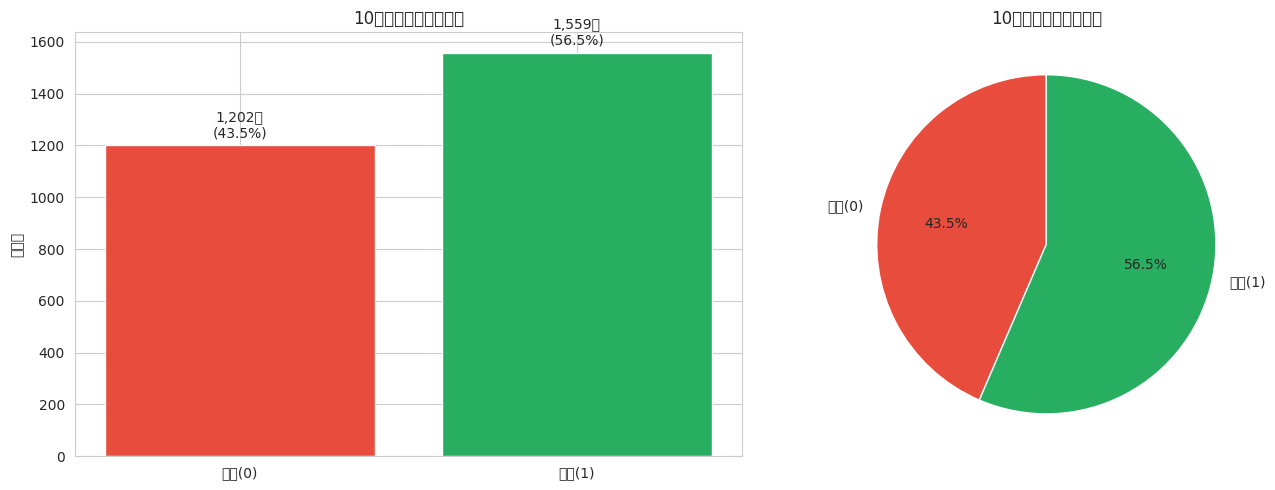

In [0]:
# 目的変数の分布
target_col = "10年定着ラベル"
target_counts = train_persona[target_col].value_counts().sort_index()
target_ratio = train_persona[target_col].mean()

print("="*60)
print("10年定着ラベルの分布")
print("="*60)
print(f"定着（1）: {target_counts[1]:,}名 ({100*target_counts[1]/len(train_persona):.2f}%)")
print(f"退職（0）: {target_counts[0]:,}名 ({100*target_counts[0]/len(train_persona):.2f}%)")
print(f"\n定着率: {target_ratio:.4f} ({100*target_ratio:.2f}%)")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 棒グラフ
axes[0].bar(['退職(0)', '定着(1)'], target_counts.values, color=['#e74c3c', '#27ae60'])
axes[0].set_ylabel('社員数')
axes[0].set_title('10年定着ラベルの分布')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, f'{v:,}名\n({100*v/len(train_persona):.1f}%)', ha='center')

# 円グラフ
axes[1].pie(target_counts.values, labels=['退職(0)', '定着(1)'], autopct='%1.1f%%', 
            colors=['#e74c3c', '#27ae60'], startangle=90)
axes[1].set_title('10年定着ラベルの割合')

plt.tight_layout()
plt.show()

## 3. 属性データの探索的分析

社員の属性情報と目的変数との関係を分析します。

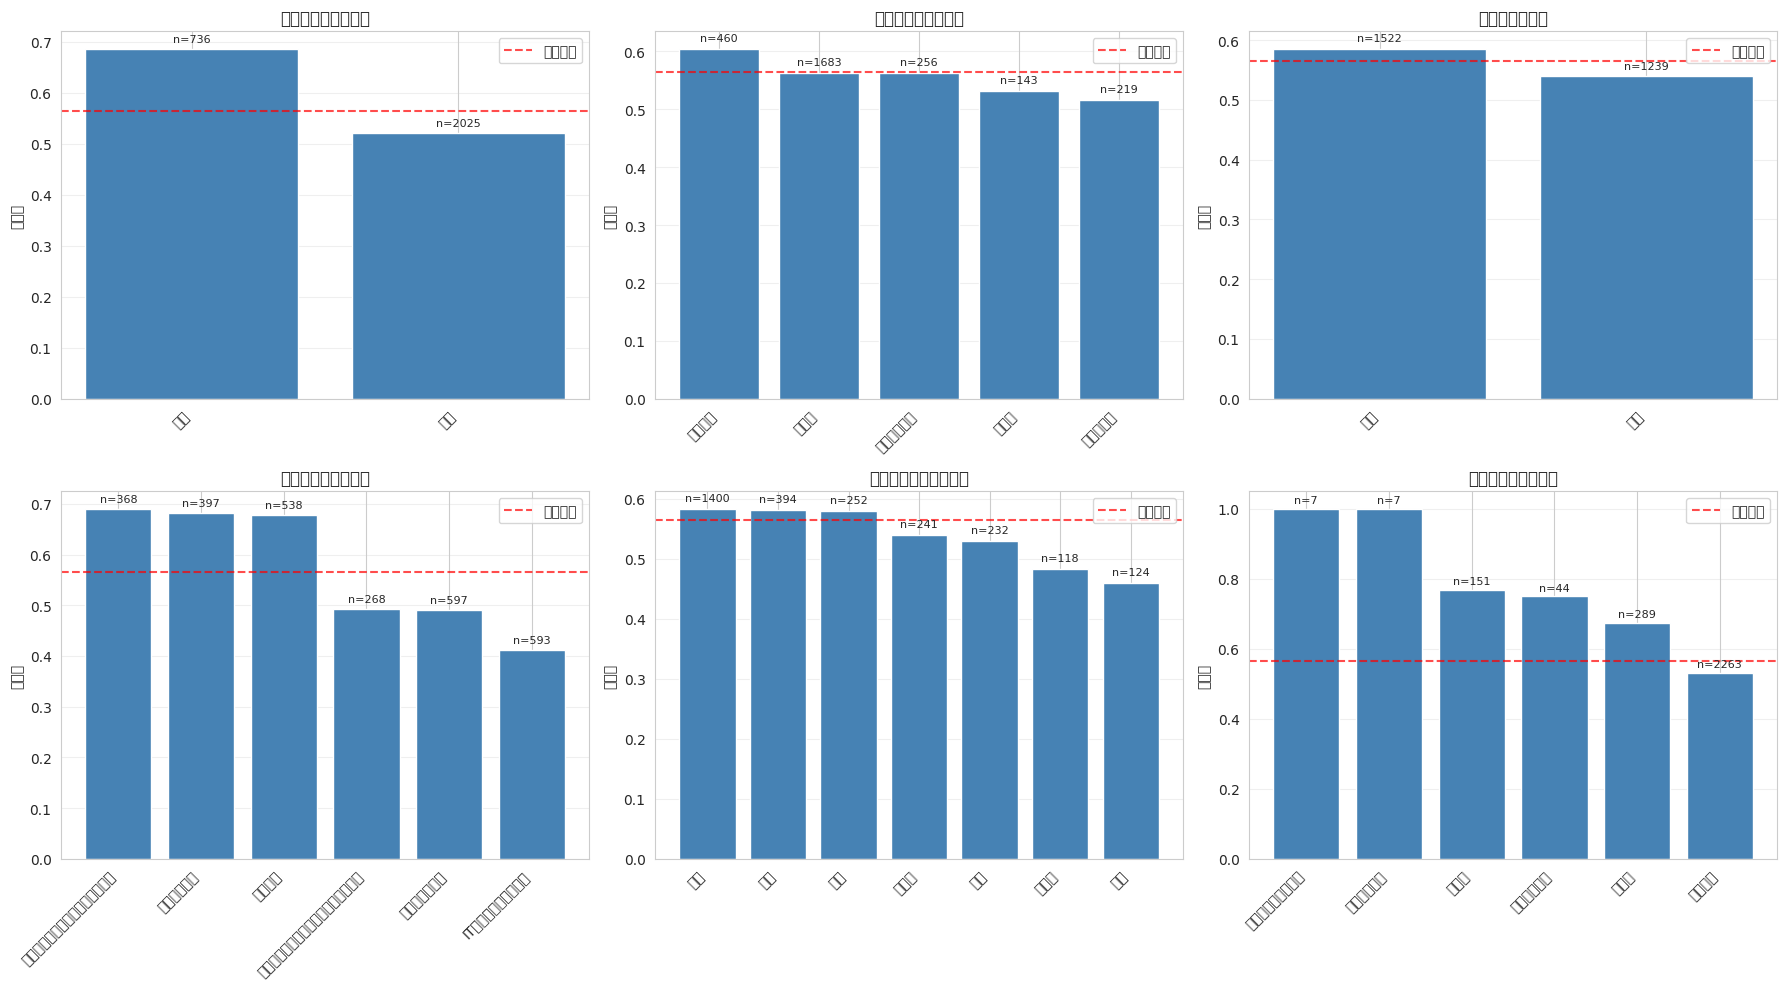

In [0]:
# 主要なカテゴリカル変数と定着率の関係
categorical_cols = ['入社区分', '最終学歴', '性別', '初期職種', '初期勤務地', '初期役割']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # 各カテゴリごとの定着率を計算
    retention_by_cat = train_persona.groupby(col)[target_col].agg(['mean', 'count'])
    retention_by_cat = retention_by_cat.sort_values('mean', ascending=False)
    
    # プロット
    ax = axes[idx]
    bars = ax.bar(range(len(retention_by_cat)), retention_by_cat['mean'], color='steelblue')
    ax.set_xticks(range(len(retention_by_cat)))
    ax.set_xticklabels(retention_by_cat.index, rotation=45, ha='right')
    ax.set_ylabel('定着率')
    ax.set_title(f'{col}別の定着率')
    ax.axhline(y=target_ratio, color='red', linestyle='--', alpha=0.7, label='全体平均')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 各バーの上にサンプル数を表示
    for i, (bar, count) in enumerate(zip(bars, retention_by_cat['count'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'n={int(count)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

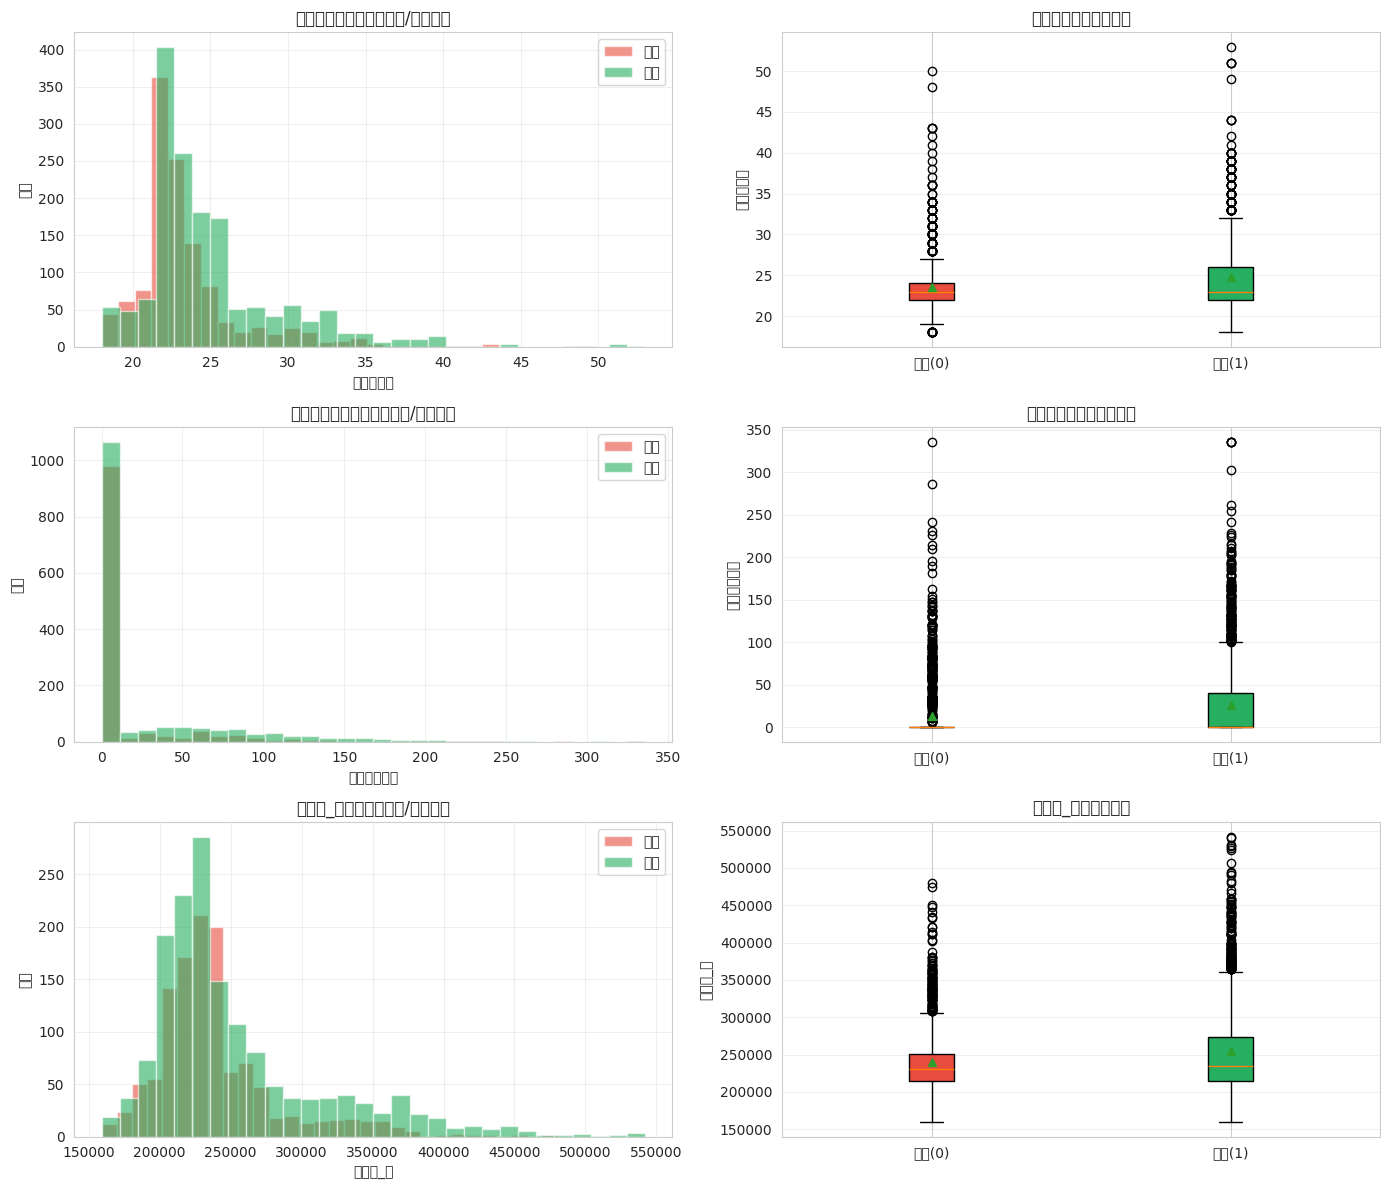

In [0]:
# 数値変数の分布と目的変数との関係
numeric_cols = ['入社時年齢', '前職経験月数', '初任給_円']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 12))

for idx, col in enumerate(numeric_cols):
    # ヒストグラム
    ax1 = axes[idx, 0]
    ax1.hist(train_persona[train_persona[target_col]==0][col].dropna(), 
             alpha=0.6, label='退職', bins=30, color='#e74c3c')
    ax1.hist(train_persona[train_persona[target_col]==1][col].dropna(), 
             alpha=0.6, label='定着', bins=30, color='#27ae60')
    ax1.set_xlabel(col)
    ax1.set_ylabel('度数')
    ax1.set_title(f'{col}の分布（定着/退職別）')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 箱ひげ図
    ax2 = axes[idx, 1]
    data_to_plot = [
        train_persona[train_persona[target_col]==0][col].dropna(),
        train_persona[train_persona[target_col]==1][col].dropna()
    ]
    bp = ax2.boxplot(data_to_plot, labels=['退職(0)', '定着(1)'],
                     patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#27ae60')
    ax2.set_ylabel(col)
    ax2.set_title(f'{col}の箱ひげ図')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
# 数値変数の基本統計量（定着/退職別）
print("="*80)
print("数値変数の基本統計量（定着/退職別）")
print("="*80)

for col in numeric_cols:
    print(f"\n【{col}】")
    print("-" * 60)
    stats_df = train_persona.groupby(target_col)[col].describe()
    print(stats_df.round(2))

数値変数の基本統計量（定着/退職別）

【入社時年齢】
------------------------------------------------------------
           count   mean   std   min   25%   50%   75%   max
10年定着ラベル                                                   
0         1202.0  23.57  3.45  18.0  22.0  23.0  24.0  50.0
1         1559.0  24.80  4.51  18.0  22.0  23.0  26.0  53.0

【前職経験月数】
------------------------------------------------------------
           count   mean    std  min  25%  50%   75%    max
10年定着ラベル                                                  
0         1202.0  13.78  35.87  0.0  0.0  0.0   0.0  336.0
1         1559.0  26.73  50.06  0.0  0.0  0.0  40.0  336.0

【初任給_円】
------------------------------------------------------------
           count       mean       std  ...       50%       75%       max
10年定着ラベル                               ...                              
0         1202.0  239801.16  44782.40  ...  231000.0  251000.0  480000.0
1         1559.0  254722.90  62921.66  ...  234000.0  273000.0  542000.0

[

## 4. 月次データの探索的分析

時系列パターンと定着・退職社員の違いを分析します。

In [0]:
# 月次データに目的変数を結合
train_monthly_labeled = train_monthly.merge(
    train_persona[['社員ID', target_col]], 
    on='社員ID', 
    how='left'
)

print(f"月次データに目的変数を結合: {train_monthly_labeled.shape}")

月次データに目的変数を結合: (65754, 30)


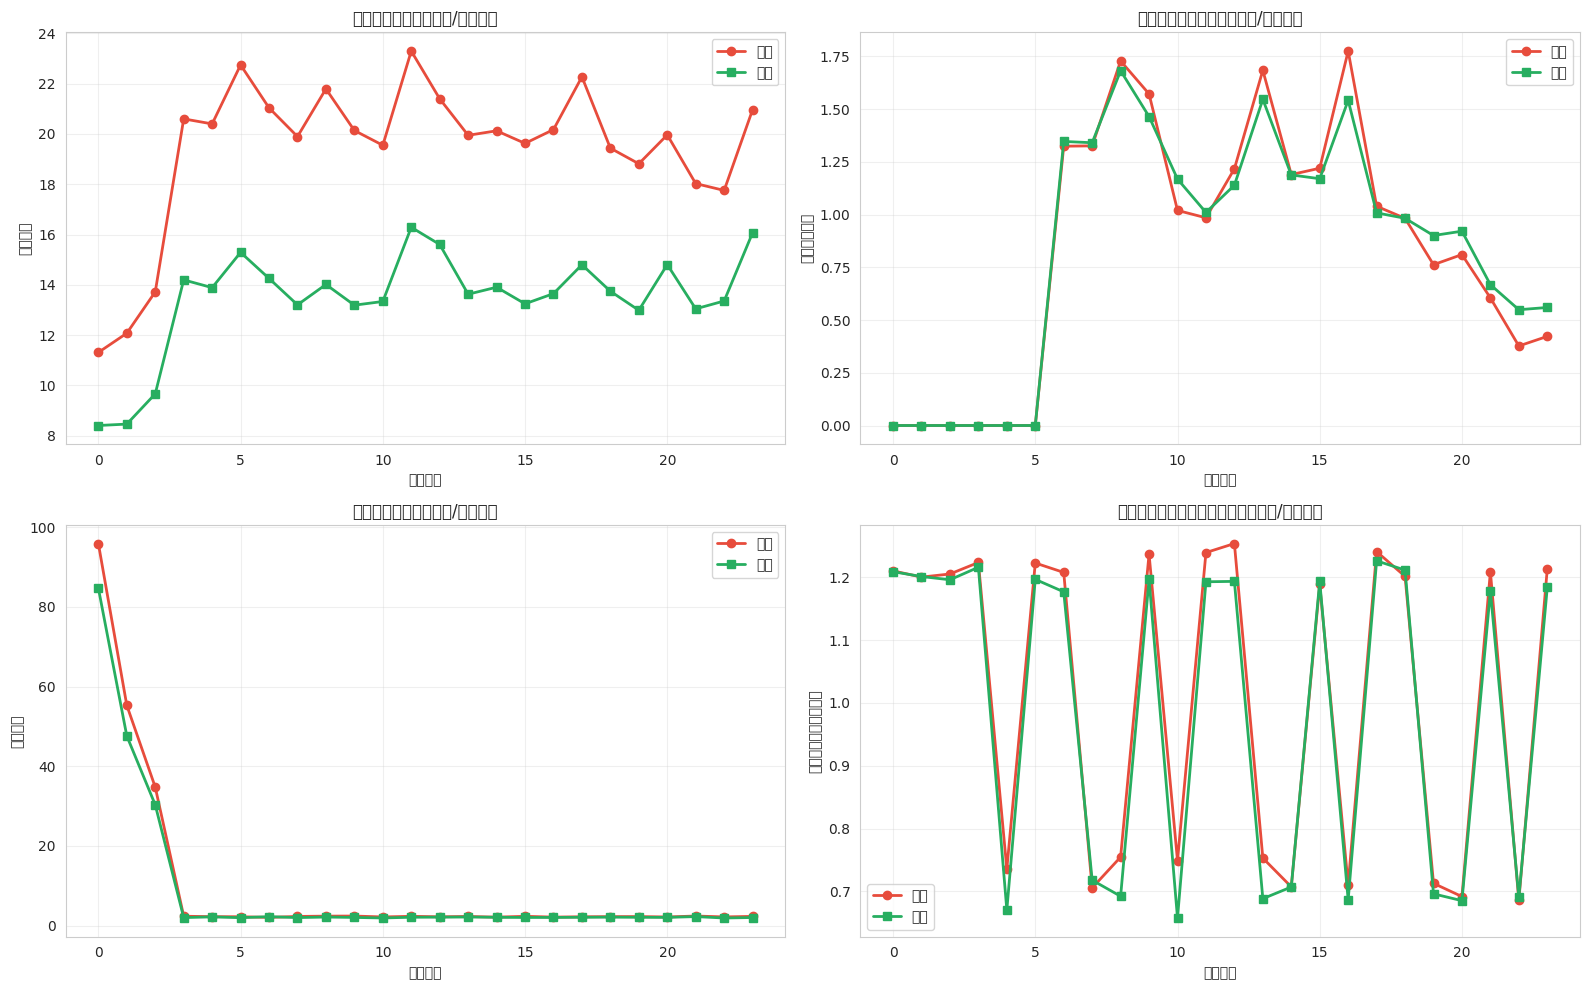

In [0]:
# 主要な月次変数の時系列パターン
monthly_numeric_cols = ['残業時間', '有給取得日数', '研修時間', '上司との面談実施回数']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(monthly_numeric_cols):
    ax = axes[idx]
    
    # 定着・退職別に経過月数ごとの平均値を計算
    time_series_data = train_monthly_labeled.groupby(['経過月数', target_col])[col].mean().unstack()
    
    # プロット
    if 0 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[0], 
                marker='o', label='退職', color='#e74c3c', linewidth=2)
    if 1 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[1], 
                marker='s', label='定着', color='#27ae60', linewidth=2)
    
    ax.set_xlabel('経過月数')
    ax.set_ylabel(col)
    ax.set_title(f'{col}の推移（定着/退職別）')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

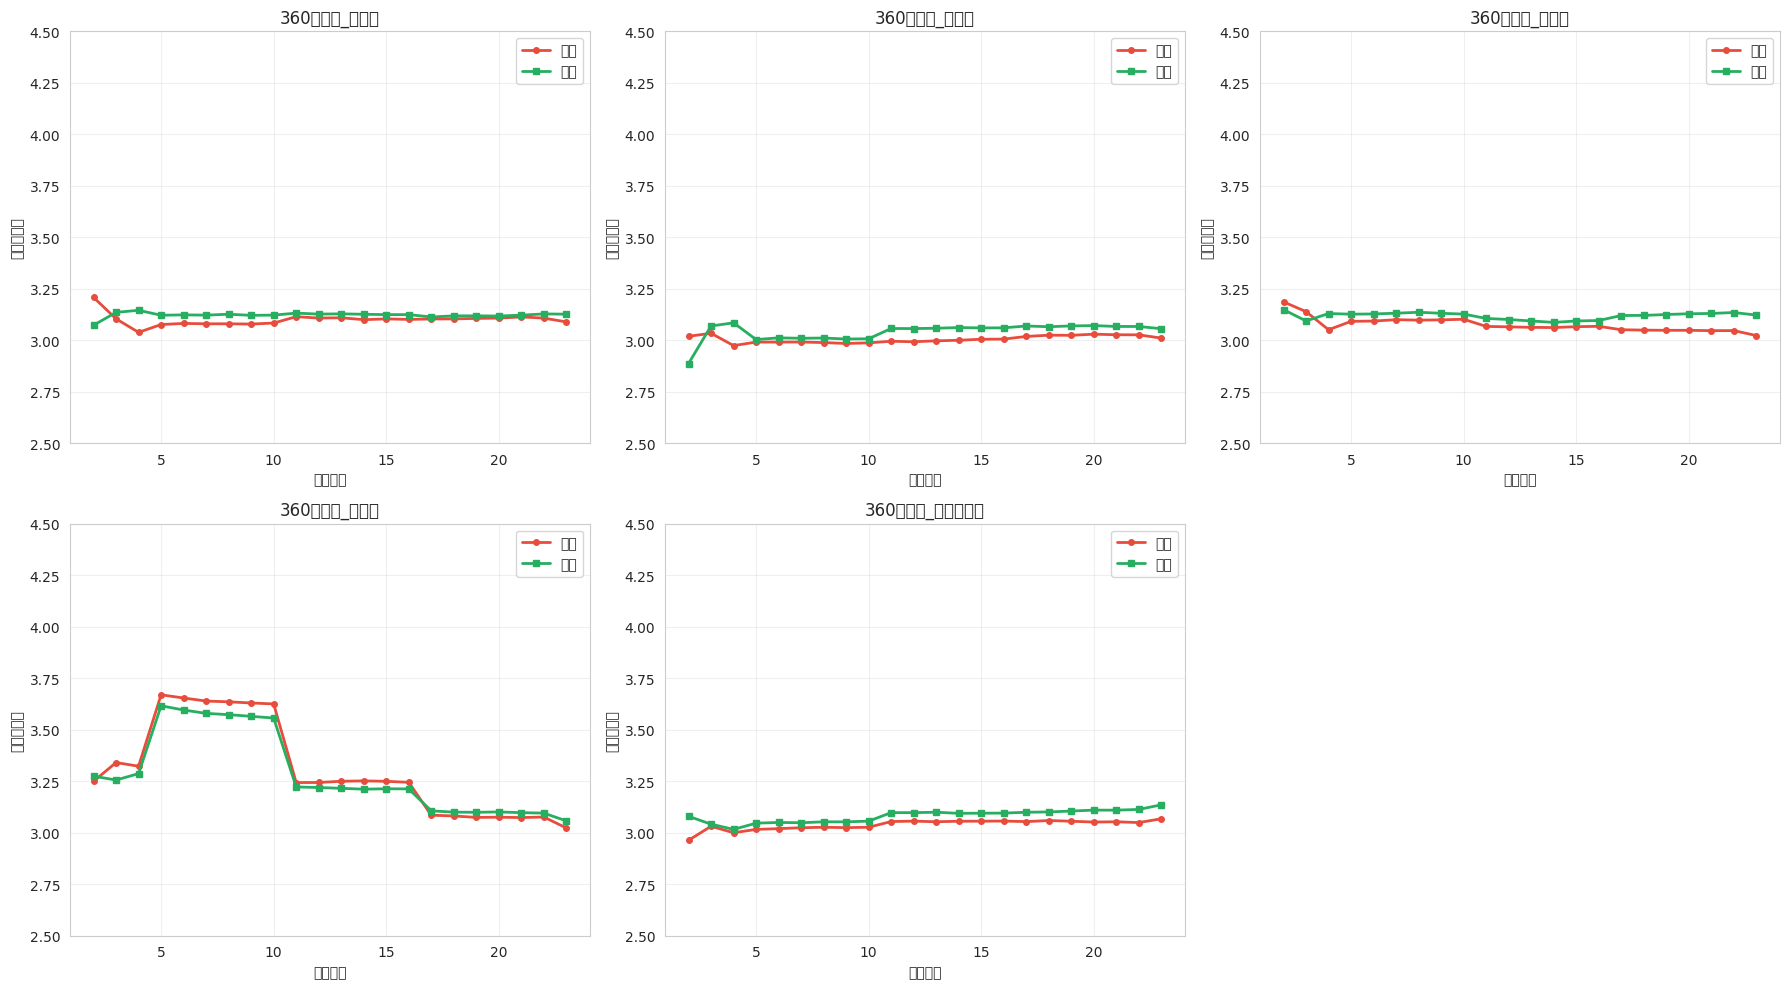

In [0]:
# 360度評価の時系列パターン
evaluation_cols = [
    '360度評価_親和度', '360度評価_信頼度', 
    '360度評価_主体度', '360度評価_学習度', '360度評価_共有貢献度'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(evaluation_cols):
    ax = axes[idx]
    
    # 定着・退職別に経過月数ごとの平均値を計算
    time_series_data = train_monthly_labeled.groupby(['経過月数', target_col])[col].mean().unstack()
    
    # プロット
    if 0 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[0], 
                marker='o', label='退職', color='#e74c3c', linewidth=2, markersize=4)
    if 1 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[1], 
                marker='s', label='定着', color='#27ae60', linewidth=2, markersize=4)
    
    ax.set_xlabel('経過月数')
    ax.set_ylabel('評価スコア')
    ax.set_title(col)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([2.5, 4.5])  # 評価は1-5の範囲

# 最後のサブプロットを非表示
axes[-1].axis('off')

plt.tight_layout()
plt.show()

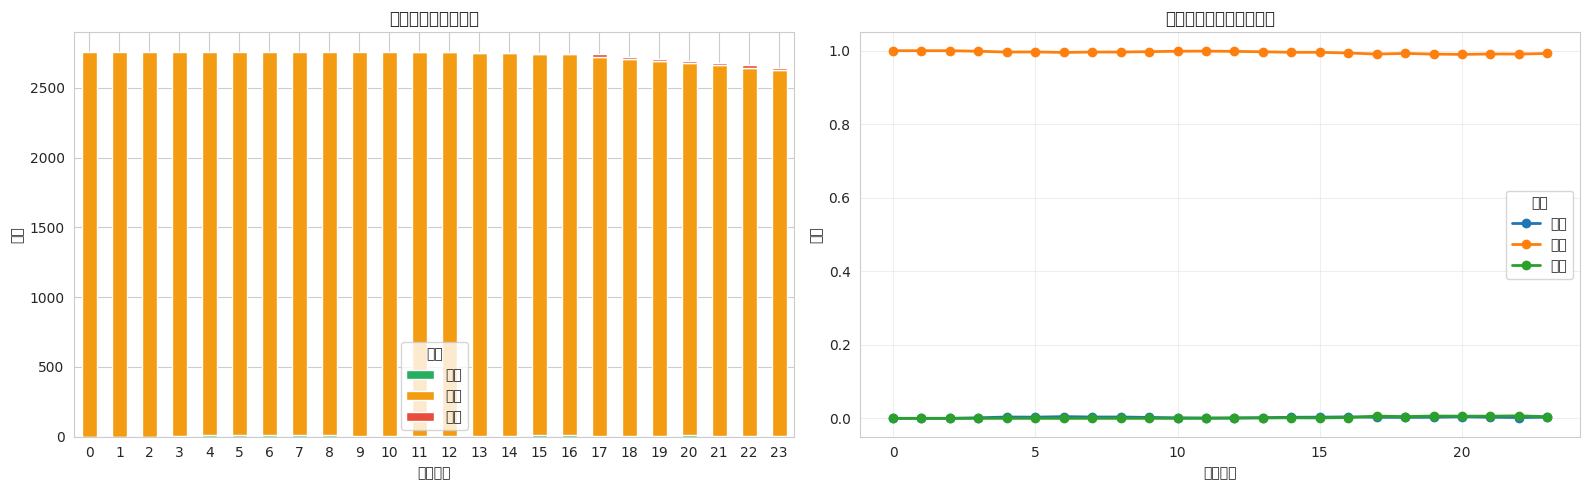

In [0]:
# 月末在籍状態の推移
status_pivot = train_monthly_labeled.groupby(['経過月数', '月末在籍状態']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 積み上げ棒グラフ
status_pivot.plot(kind='bar', stacked=True, ax=axes[0], 
                  color=['#27ae60', '#f39c12', '#e74c3c'])
axes[0].set_xlabel('経過月数')
axes[0].set_ylabel('人数')
axes[0].set_title('月末在籍状態の推移')
axes[0].legend(title='状態')
axes[0].tick_params(axis='x', rotation=0)

# 割合の推移
status_ratio = status_pivot.div(status_pivot.sum(axis=1), axis=0)
status_ratio.plot(kind='line', ax=axes[1], marker='o', linewidth=2)
axes[1].set_xlabel('経過月数')
axes[1].set_ylabel('割合')
axes[1].set_title('月末在籍状態の割合推移')
axes[1].legend(title='状態')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 相関分析

数値変数間の相関と目的変数との相関を確認します。

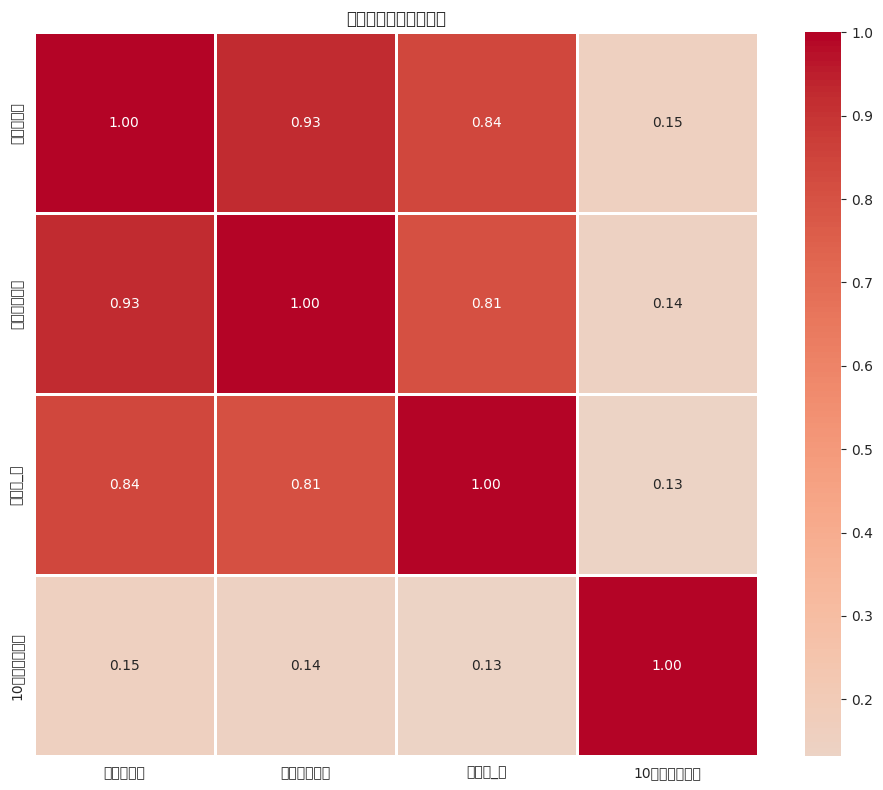


目的変数（10年定着ラベル）との相関
入社時年齢                         :  0.1487
前職経験月数                        :  0.1430
初任給_円                         :  0.1316


In [0]:
# 属性データの数値カラムの相関行列
numeric_persona_cols = train_persona.select_dtypes(include=[np.number]).columns.tolist()

# 相関行列を計算
corr_matrix = train_persona[numeric_persona_cols].corr()

# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('属性データの相関行列')
plt.tight_layout()
plt.show()

# 目的変数との相関が高い変数
print("\n目的変数（10年定着ラベル）との相関")
print("="*60)
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
for col, corr_val in target_corr.items():
    print(f"{col:30s}: {corr_val:7.4f}")

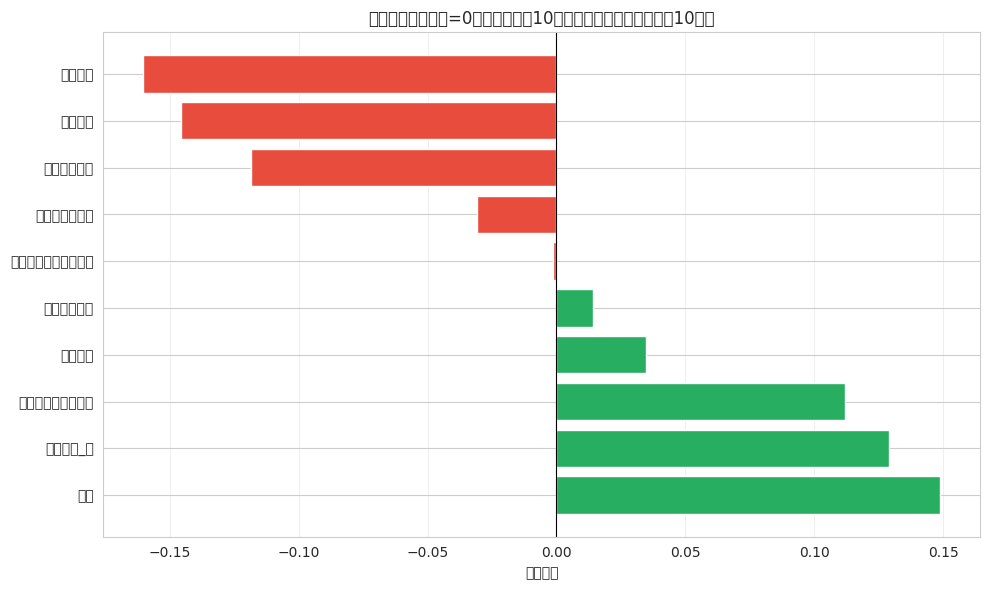


入社月の各指標と目的変数の相関（上位15件）
年齢                                 :  0.1487
月例給与_円                             :  0.1287
担当プロジェクト数                          :  0.1117
欠勤日数                               :  0.0347
情報共有件数                             :  0.0143
上司との面談実施回数                         : -0.0013
顧客満足度評価                            : -0.0310
在宅勤務日数                             : -0.1185
研修時間                               : -0.1455
残業時間                               : -0.1602
経過月数                               :     nan
360度評価_親和度                         :     nan
360度評価_信頼度                         :     nan
360度評価_主体度                         :     nan
360度評価_学習度                         :     nan


In [0]:
# 経過月数0（入社月）のデータと目的変数の相関
month0_data = train_monthly_labeled[train_monthly_labeled['経過月数'] == 0].copy()

# 数値カラムのみ抽出
month0_numeric = month0_data.select_dtypes(include=[np.number])

if target_col in month0_numeric.columns:
    month0_corr = month0_numeric.corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    # 上位10件を可視化
    fig, ax = plt.subplots(figsize=(10, 6))
    top10_corr = month0_corr.head(10)
    colors = ['#27ae60' if x > 0 else '#e74c3c' for x in top10_corr.values]
    ax.barh(range(len(top10_corr)), top10_corr.values, color=colors)
    ax.set_yticks(range(len(top10_corr)))
    ax.set_yticklabels(top10_corr.index)
    ax.set_xlabel('相関係数')
    ax.set_title('入社月（経過月数=0）の各指標と10年定着ラベルの相関（上位10件）')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n入社月の各指標と目的変数の相関（上位15件）")
    print("="*60)
    for col, corr_val in month0_corr.head(15).items():
        print(f"{col:35s}: {corr_val:7.4f}")

In [0]:
# 6. テキストデータの分析

print("="*80)
print("テキストデータの統計分析")
print("="*80)

text_cols = ['入社時メモ', '上司からのフィードバック', '同僚からのフィードバック']

# 各テキストカラムの基本統計
for col in text_cols:
    print(f"\n【{col}】")
    print("-" * 60)
    
    # 欠損率
    missing_rate = train_persona[col].isnull().sum() / len(train_persona) * 100
    print(f"欠損率: {missing_rate:.2f}%")
    
    # 欠損でないデータのみ抽出
    valid_texts = train_persona[col].dropna()
    
    if len(valid_texts) > 0:
        # 文字数の統計
        char_counts = valid_texts.str.len()
        print(f"\n文字数統計:")
        print(f"  平均: {char_counts.mean():.1f}文字")
        print(f"  中央値: {char_counts.median():.0f}文字")
        print(f"  最小: {char_counts.min()}文字")
        print(f"  最大: {char_counts.max()}文字")
        
        # 定着/退職別の文字数比較
        char_by_target = train_persona.groupby(target_col)[col].apply(
            lambda x: x.dropna().str.len().mean()
        )
        print(f"\n定着/退職別の平均文字数:")
        print(f"  退職(0): {char_by_target[0]:.1f}文字")
        print(f"  定着(1): {char_by_target[1]:.1f}文字")
        print(f"  差分: {char_by_target[1] - char_by_target[0]:.1f}文字")

テキストデータの統計分析

【入社時メモ】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 205.1文字
  中央値: 207文字
  最小: 44文字
  最大: 261文字

定着/退職別の平均文字数:
  退職(0): 205.8文字
  定着(1): 204.5文字
  差分: -1.2文字

【上司からのフィードバック】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 459.4文字
  中央値: 459文字
  最小: 316文字
  最大: 617文字

定着/退職別の平均文字数:
  退職(0): 459.3文字
  定着(1): 459.5文字
  差分: 0.2文字

【同僚からのフィードバック】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 224.0文字
  中央値: 222文字
  最小: 149文字
  最大: 325文字

定着/退職別の平均文字数:
  退職(0): 223.6文字
  定着(1): 224.3文字
  差分: 0.7文字


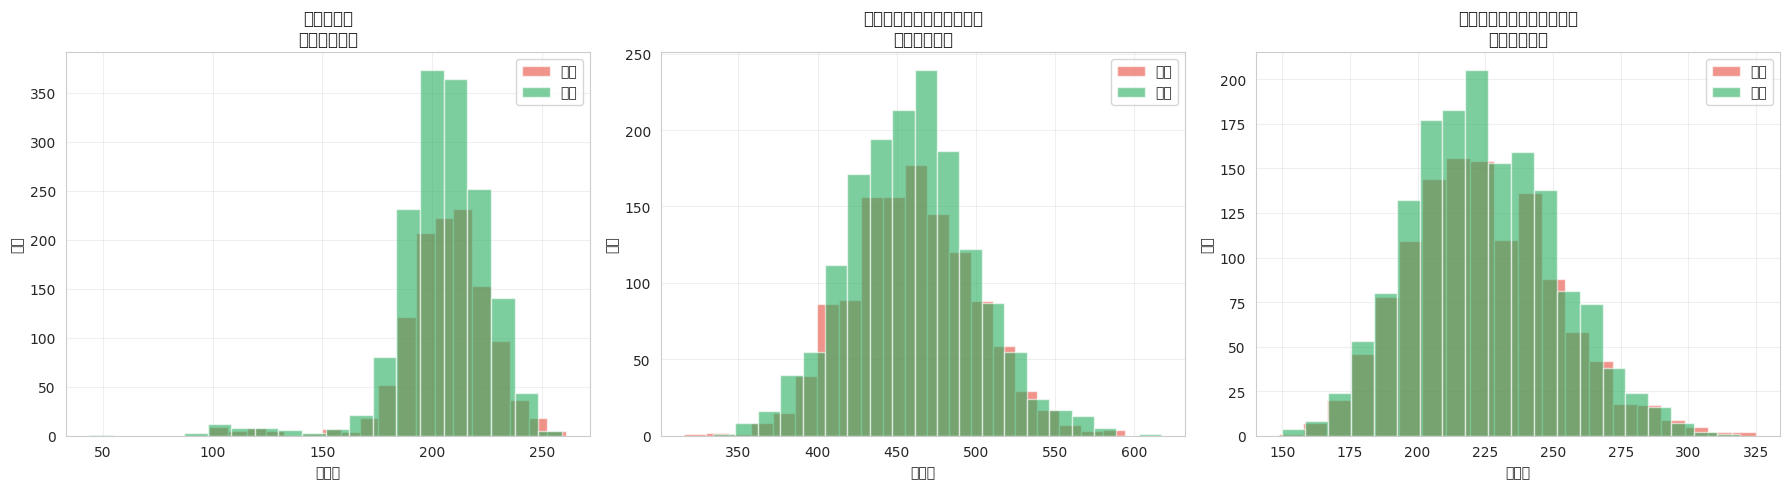

In [0]:
# テキストデータの可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(text_cols):
    ax = axes[idx]
    
    # 欠損でないデータのみ抽出
    valid_data = train_persona[[col, target_col]].dropna()
    
    if len(valid_data) > 0:
        # 文字数を計算
        valid_data['char_count'] = valid_data[col].str.len()
        
        # ヒストグラム
        ax.hist(valid_data[valid_data[target_col]==0]['char_count'], 
                alpha=0.6, label='退職', bins=20, color='#e74c3c')
        ax.hist(valid_data[valid_data[target_col]==1]['char_count'], 
                alpha=0.6, label='定着', bins=20, color='#27ae60')
        ax.set_xlabel('文字数')
        ax.set_ylabel('度数')
        ax.set_title(f'{col}\n文字数の分布')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 月次カテゴリ変数の変化パターン

In [0]:
# 月次データで変化パターンを分析
print("="*80)
print("月次カテゴリ変数の変化パターン")
print("="*80)

# 分析対象のカテゴリ変数
change_cols = ['部署ID', '職種', '役割', '等級', '勤務地', '上司ID']

# 各社員の変更回数を計算
change_stats = []

for col in change_cols:
    # 各社員の変更回数をカウント
    changes_per_employee = train_monthly_labeled.sort_values(['社員ID', '経過月数']).groupby('社員ID')[col].apply(
        lambda x: (x != x.shift()).sum() - 1  # -1は初回を除く
    )
    
    # 目的変数と結合
    changes_with_target = pd.DataFrame({
        '変更回数': changes_per_employee
    }).merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = changes_with_target.groupby(target_col)['変更回数'].agg(['mean', 'median', 'max'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"全体の平均変更回数: {changes_per_employee.mean():.2f}回")
    print(f"退職者の平均: {stats_by_target.loc[0, 'mean']:.2f}回")
    print(f"定着者の平均: {stats_by_target.loc[1, 'mean']:.2f}回")
    print(f"差分: {stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']:.2f}回")
    
    change_stats.append({
        '変数': col,
        '退職者平均': stats_by_target.loc[0, 'mean'],
        '定着者平均': stats_by_target.loc[1, 'mean'],
        '差分': stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']
    })

# 結果をDataFrame化
change_stats_df = pd.DataFrame(change_stats)

月次カテゴリ変数の変化パターン

【部署ID】
------------------------------------------------------------
全体の平均変更回数: 0.26回
退職者の平均: 0.24回
定着者の平均: 0.27回
差分: 0.03回

【職種】
------------------------------------------------------------
全体の平均変更回数: 0.01回
退職者の平均: 0.01回
定着者の平均: 0.01回
差分: -0.00回

【役割】
------------------------------------------------------------
全体の平均変更回数: 0.00回
退職者の平均: 0.00回
定着者の平均: 0.00回
差分: 0.00回

【等級】
------------------------------------------------------------
全体の平均変更回数: 0.00回
退職者の平均: 0.00回
定着者の平均: 0.00回
差分: 0.00回

【勤務地】
------------------------------------------------------------
全体の平均変更回数: 0.02回
退職者の平均: 0.02回
定着者の平均: 0.02回
差分: 0.00回

【上司ID】
------------------------------------------------------------
全体の平均変更回数: 0.35回
退職者の平均: 0.33回
定着者の平均: 0.36回
差分: 0.03回


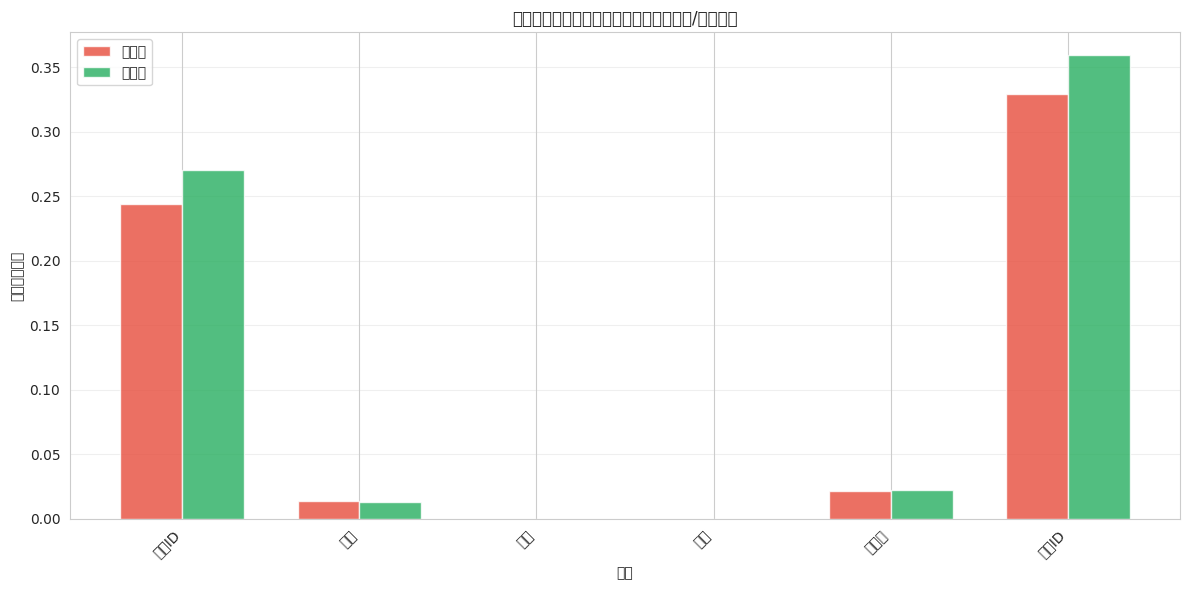

In [0]:
# 変化パターンの可視化
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(change_stats_df))
width = 0.35

ax.bar(x - width/2, change_stats_df['退職者平均'], width, 
       label='退職者', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, change_stats_df['定着者平均'], width,
       label='定着者', color='#27ae60', alpha=0.8)

ax.set_xlabel('変数')
ax.set_ylabel('平均変更回数')
ax.set_title('月次カテゴリ変数の平均変更回数（定着/退職別）')
ax.set_xticks(x)
ax.set_xticklabels(change_stats_df['変数'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 時系列特徴量の変化点・トレンド分析

In [0]:
# 時系列トレンドと変化点の分析
from scipy import stats

print("="*80)
print("時系列特徴量のトレンド分析")
print("="*80)

# 分析対象の数値変数
trend_cols = ['残業時間', '研修時間', '上司との面談実施回数', '月例給与_円']

# 各社員の時系列トレンド（線形回帰の傾き）を計算
trend_results = []

for col in trend_cols:
    # 各社員ごとに線形回帰の傾きを計算
    def calc_trend(group):
        valid_data = group[['経過月数', col]].dropna()
        if len(valid_data) >= 3:  # 最低3データポイント必要
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                valid_data['経過月数'], valid_data[col]
            )
            return pd.Series({
                '傾き': slope,
                'R2': r_value**2,
                '初期値': valid_data[col].iloc[0] if len(valid_data) > 0 else np.nan,
                '最終値': valid_data[col].iloc[-1] if len(valid_data) > 0 else np.nan
            })
        return pd.Series({'傾き': np.nan, 'R2': np.nan, '初期値': np.nan, '最終値': np.nan})
    
    trends = train_monthly_labeled.groupby('社員ID').apply(calc_trend).reset_index()
    
    # 目的変数と結合
    trends = trends.merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = trends.groupby(target_col)['傾き'].agg(['mean', 'median', 'std'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"退職者の平均傾き: {stats_by_target.loc[0, 'mean']:.4f}")
    print(f"定着者の平均傾き: {stats_by_target.loc[1, 'mean']:.4f}")
    print(f"差分: {stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']:.4f}")
    
    trend_results.append({
        '変数': col,
        '退職者傾き': stats_by_target.loc[0, 'mean'],
        '定着者傾き': stats_by_target.loc[1, 'mean']
    })

trend_results_df = pd.DataFrame(trend_results)

時系列特徴量のトレンド分析

【残業時間】
------------------------------------------------------------
退職者の平均傾き: 0.2408
定着者の平均傾き: 0.1429
差分: -0.0980

【研修時間】
------------------------------------------------------------
退職者の平均傾き: -1.7759
定着者の平均傾き: -1.4753
差分: 0.3006

【上司との面談実施回数】
------------------------------------------------------------
退職者の平均傾き: -0.0087
定着者の平均傾き: -0.0081
差分: 0.0006

【月例給与_円】
------------------------------------------------------------
退職者の平均傾き: 403.4597
定着者の平均傾き: 459.6564
差分: 56.1967


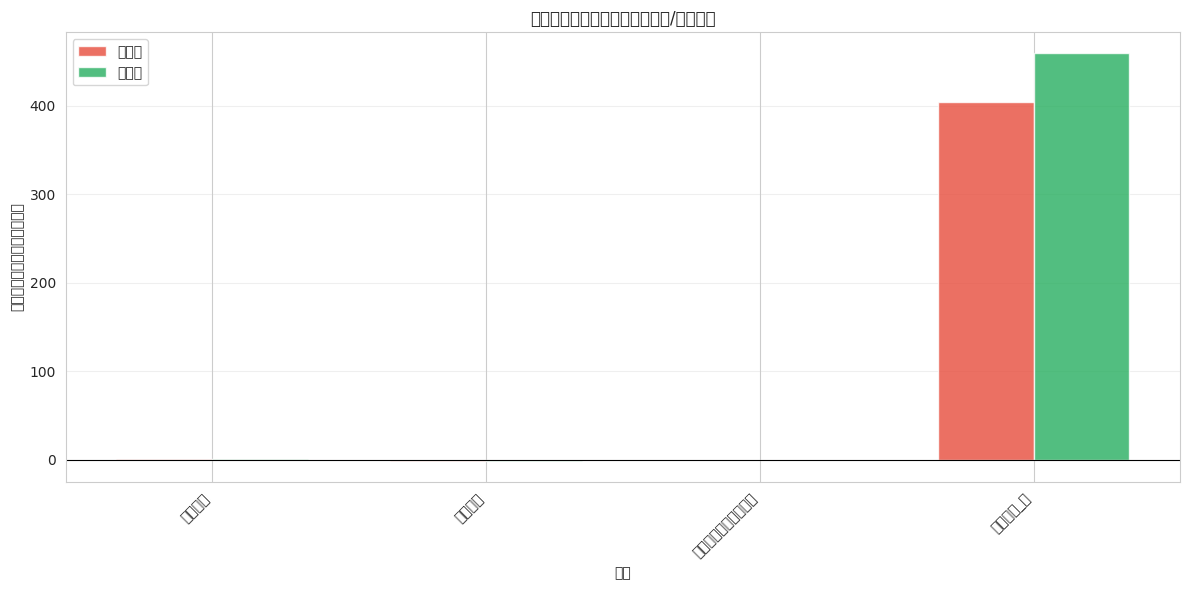


✅ 正の傾き = 時間経過とともに増加
❌ 負の傾き = 時間経過とともに減少


In [0]:
# トレンドの可視化
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(trend_results_df))
width = 0.35

ax.bar(x - width/2, trend_results_df['退職者傾き'], width, 
       label='退職者', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, trend_results_df['定着者傾き'], width,
       label='定着者', color='#27ae60', alpha=0.8)

ax.set_xlabel('変数')
ax.set_ylabel('平均傾き（月あたりの変化）')
ax.set_title('時系列特徴量のトレンド（定着/退職別）')
ax.set_xticks(x)
ax.set_xticklabels(trend_results_df['変数'], rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 正の傾き = 時間経過とともに増加")
print("❌ 負の傾き = 時間経過とともに減少")

## 9. 欠損パターンの特徴化

In [0]:
# 欠損パターンの分析
print("="*80)
print("高欠損変数の欠損パターン分析")
print("="*80)

# 高欠損変数
high_missing_cols = [
    '360度評価_親和度',
    '360度評価_信頼度',
    '顧客満足度評価',
    '担当プロジェクト数'
]

# 各社員の欠損率を計算
missing_rate_per_employee = {}

for col in high_missing_cols:
    # 各社員の0-23ヶ月間の欠損率
    missing_rates = train_monthly_labeled.groupby('社員ID')[col].apply(
        lambda x: x.isnull().sum() / len(x)
    )
    
    # 目的変数と結合
    missing_with_target = pd.DataFrame({
        '欠損率': missing_rates
    }).merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = missing_with_target.groupby(target_col)['欠損率'].agg(['mean', 'median'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"退職者の平均欠損率: {stats_by_target.loc[0, 'mean']*100:.2f}%")
    print(f"定着者の平均欠損率: {stats_by_target.loc[1, 'mean']*100:.2f}%")
    print(f"差分: {(stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean'])*100:.2f}%ポイント")
    
    missing_rate_per_employee[col] = missing_with_target

高欠損変数の欠損パターン分析

【360度評価_親和度】
------------------------------------------------------------
退職者の平均欠損率: 21.09%
定着者の平均欠損率: 20.45%
差分: -0.64%ポイント

【360度評価_信頼度】
------------------------------------------------------------
退職者の平均欠損率: 21.09%
定着者の平均欠損率: 20.45%
差分: -0.64%ポイント

【顧客満足度評価】
------------------------------------------------------------
退職者の平均欠損率: 58.64%
定着者の平均欠損率: 70.41%
差分: 11.77%ポイント

【担当プロジェクト数】
------------------------------------------------------------
退職者の平均欠損率: 34.44%
定着者の平均欠損率: 57.31%
差分: 22.87%ポイント


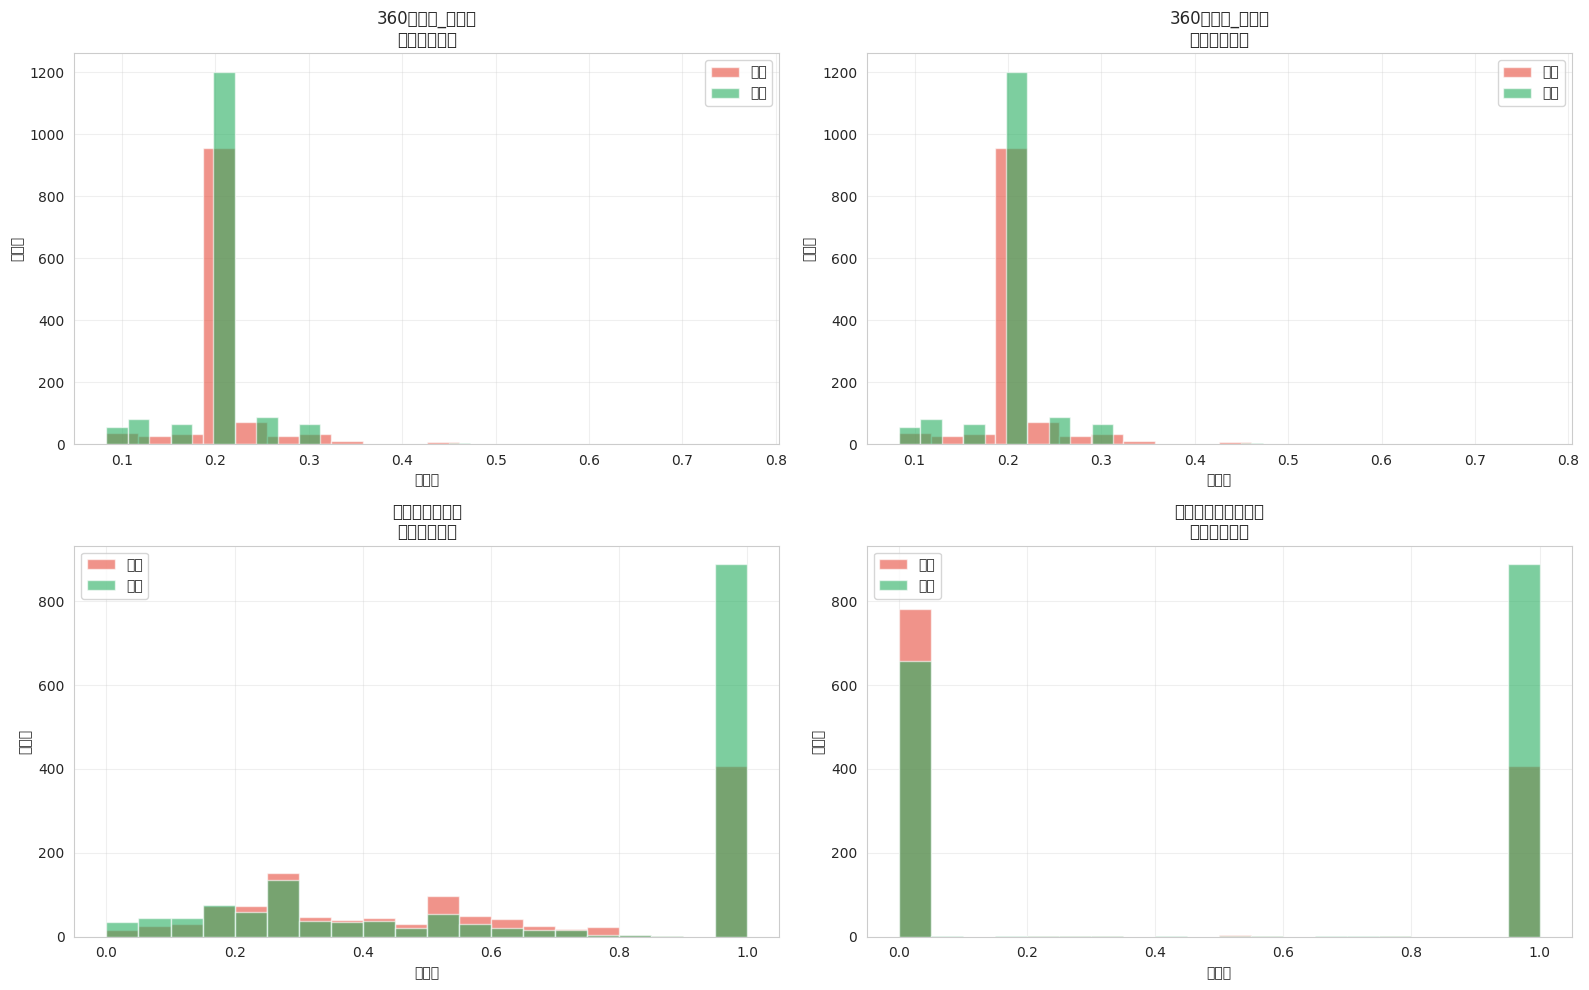

In [0]:
# 欠損パターンの可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(high_missing_cols):
    ax = axes[idx]
    data = missing_rate_per_employee[col]
    
    # ヒストグラム
    ax.hist(data[data[target_col]==0]['欠損率'], 
            alpha=0.6, label='退職', bins=20, color='#e74c3c')
    ax.hist(data[data[target_col]==1]['欠損率'], 
            alpha=0.6, label='定着', bins=20, color='#27ae60')
    ax.set_xlabel('欠損率')
    ax.set_ylabel('社員数')
    ax.set_title(f'{col}\n欠損率の分布')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

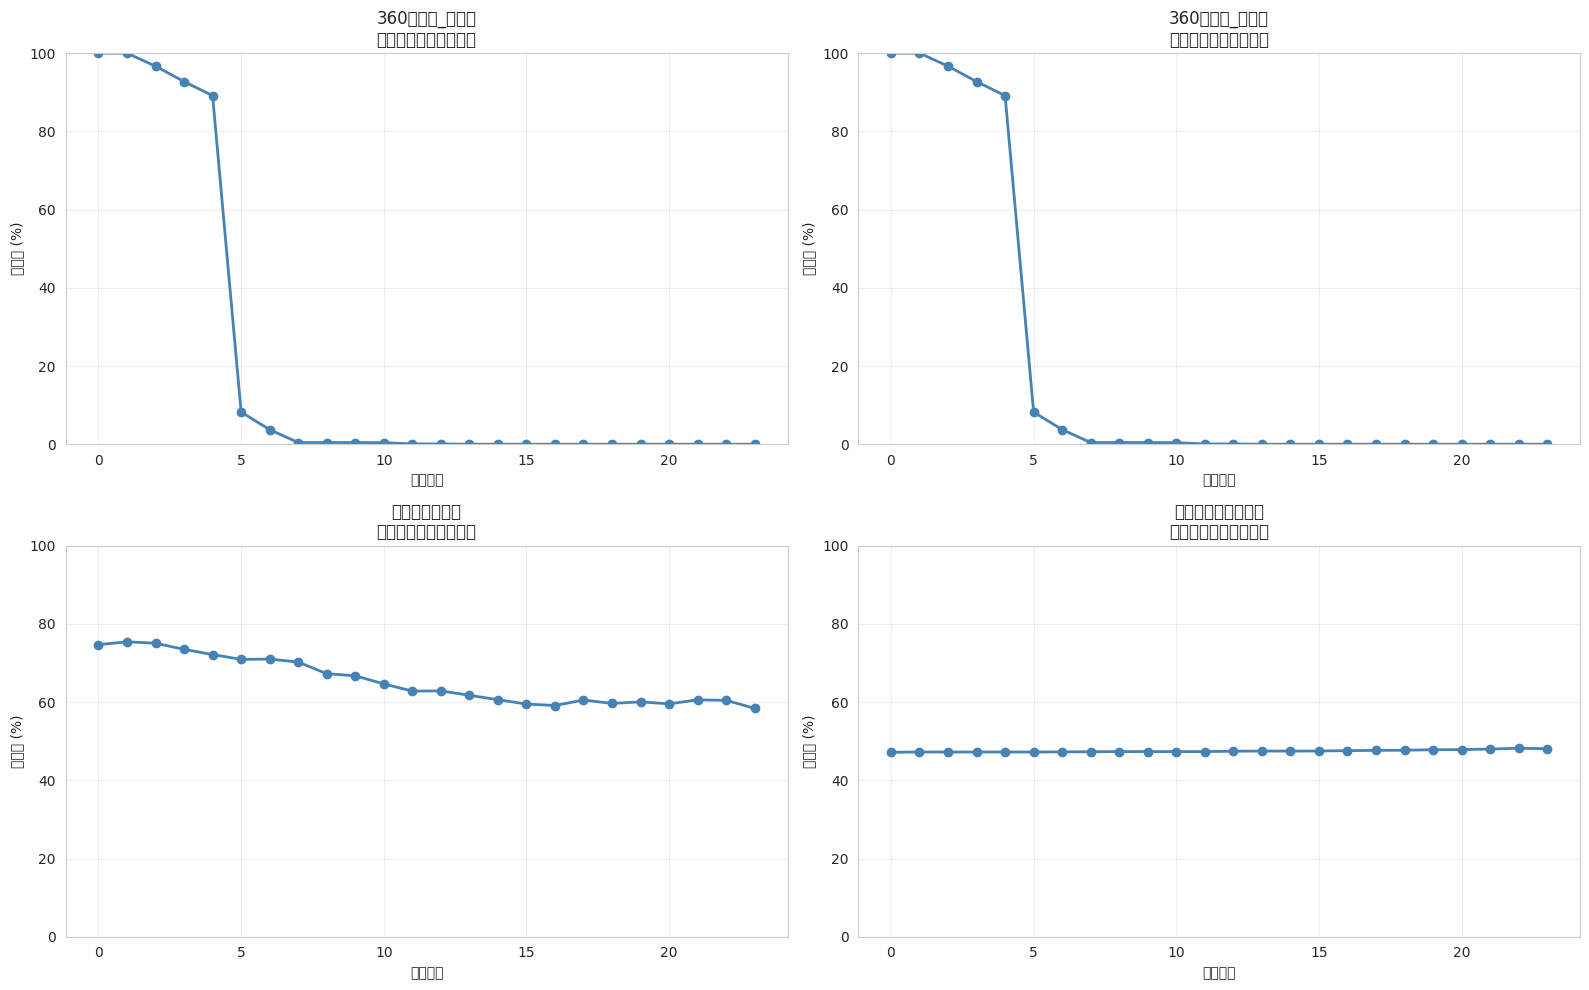


✅ 欠損率が時間経過とともに減少 = 評価・業務が始まるタイミング


In [0]:
# 経過月数ごとの欠損率の推移
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(high_missing_cols):
    ax = axes[idx]
    
    # 経過月数ごとの欠損率
    missing_by_month = train_monthly_labeled.groupby('経過月数')[col].apply(
        lambda x: x.isnull().sum() / len(x) * 100
    )
    
    ax.plot(missing_by_month.index, missing_by_month.values, 
            marker='o', linewidth=2, color='steelblue')
    ax.set_xlabel('経過月数')
    ax.set_ylabel('欠損率 (%)')
    ax.set_title(f'{col}\n経過月数ごとの欠損率')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print("\n✅ 欠損率が時間経過とともに減少 = 評価・業務が始まるタイミング")